# Кластеризация

Кластеризация — это задача группировки объектов на подмножества (кластеры) таким образом, чтобы объекты из одного кластера были более похожи друг на друга, чем на объекты из других кластеров, по какому-либо критерию.

# K-means: кластеризация по среднему
K-means — это алгоритм несупервизированного обучения, который делит данные на K кластеров, минимизируя расстояния от точек до центров (средних) кластеров.

### Цель:
Разделить данные на K групп так, чтобы:

- Внутри каждого кластера объекты были похожи

- Между кластерами — различались

### Алгоритм пошагово:

1. Выбери K — количество кластеров

2. Инициализация: случайно выбери K центров (центроидов)

3. Присвоение кластеров:

- Каждая точка относится к ближайшему центру по расстоянию (обычно евклидовому)

4. Обновление центров:

- Для каждого кластера пересчитай центр как среднее всех точек в нём

5. Повторяй шаги 3–4, пока:

- Центры не изменяются (или изменение очень малое)

- Достигнуто максимальное число итераций

### Особенности:
- Нужно заранее знать K (часто подбирают по метрике силуэта)

- Чувствителен к начальной инициализации

- Может сойтись в локальный минимум

- Работает лучше на шарообразных кластерах с одинаковыми дисперсиями

# Mini-Batch K-means

Данная вариация k-means используется, когда данных очень много. Из-за их объёма вычисление центров по всей выборке занимает много времени.

Для решения этой проблемы k-means на каждом шаге работает с небольшой подвыборкой данных. В общем случае упрощённый алгоритм должен сходиться к тому же результату, что и на полной выборке. Однако исследования показывают, что качество кластеров может ухудшаться по сравнению с классическим k-means.

Для того чтобы запустить алгоритм кластеризации Mini-Batch K-means, нам нужна библиотека sklearn и модуль MiniBatchKMeans. Его применение и параметры аналогичны классическому Kmeans. Отличие лишь в том, что можно дополнительно настроить объём подвыборки:

```python
# два кластера и подвыборки объёма 6

kmeans = MiniBatchKMeans(n_clusters=2,random_state=42,batch_size=6)
```

# K-means++

Данную вариацию k-means используют, если признаков очень много.

Результат и время работы алгоритма зависят от изначального выбора центроидов. Чтобы минимизировать затраты, будем действовать следующим образом:

1. Первый центроид выбираем случайным образом.
2. Для каждой точки вычисляем квадрат расстояния до ближайшего центроида из тех, что уже поставлены.
3. Далее из этих точек выбираем следующий центроид так, чтобы вероятность выбора точки была пропорциональна вычисленному для неё квадрату расстояния.
4. Когда все точки выбраны, реализуем k-means.

По умолчанию при запуске k-means в sklearn используется именно алгоритм k-means++. Выбор алгоритма задаётся через параметр init:

* init='random' — для классической версии k-means;
* init='k-means++' — для вариации k-means++.

# Количество точек кластеров?

Однако остался важный вопрос: как определить количество кластеров?

Способы выбора количества кластеров:

1. Метод локтя (Elbow method)
- Строим график:

K (число кластеров) по оси X
→ Сумма квадратов ошибок (inertia) по оси Y

- Выбираем точку, где снижение резко замедляется (похоже на "локоть") — это и есть оптимальный K.

2. Силуэт-метрика (Silhouette score)
- Для каждого K вычисляется средняя сила силуэта (от -1 до 1) — насколько точка близка к своему кластеру и далека от других.

- Чем ближе к 1, тем лучше. Выбираем K с максимальным значением.

3. Gap Statistic
- Сравниваем разброс внутри кластеров с разбросом в случайных данных.

- Выбираем K, где разница (gap) наибольшая.

Однако важно отметить, что с помощью метода локтя не всегда получается определить оптимальное количество кластеров, так как не всегда есть этот перегиб. Как быть в таком случае? Какое оптимальное количество кластеров выбрать?

Если в ходе решения задачи вы встречаете график, на котором невозможно найти «локоть», на помощь придёт коэффициент силуэта.

# EM-алгоритм
Это модель гауссовой смеси (Gaussian Mixture Model, GMM), в которой данные описываются законом нормального распределения.

### Цель
Максимизировать вероятность наблюдаемых данных, корректируя параметры модели.

### Алгоритм состоит из шагов:
В более общем виде последовательность действий в EM-алгоритме можно сформулировать следующим образом:

1. Выбрать количество кластеров, которое кажется нам оптимальным для наших данных.

2. Случайным образом выбрать параметры распределений в пространстве данных.

3. Для каждой точки набора данных рассчитать вероятность принадлежности к каждому кластеру.

4. Обновить параметры распределений таким образом, чтобы максимизировать вероятность принадлежности точек, 
отнесённых к кластеру.

5. Повторять шаги 3-4 фиксированное число раз либо до тех пор, пока центроиды не сойдутся.

### Пример применения:
* Разделение данных на кластеры, предполагая, что они получены из смеси нормальных распределений (GMM).

* Восстановление пропущенных данных.

## Преимущества
* Устойчив к шумам и пропущенным значениям в данных.
* Кластеры, которые находит этот алгоритм, могут принимать форму эллипса, а не ограничиваться окружностями. K-Means является частным случаем GMM.
* Если объект находится в середине двух перекрывающихся кластеров, то, в отличие от k-means, не нужно решать, к какому кластеру он принадлежит — объект может принадлежать к двум разным кластерам с разной вероятностью.

## Недостатки
* При неудачной инициализации сходимость может оказаться медленной.
* Нужно задавать количество кластеров.
* Иногда останавливается в локальном минимуме и не достигает глобального.

# DBSCAN

Этот алгоритм хорошо подходит для ситуаций, когда необходимо выделить кластеры различной, порой довольно сложной формы. Такая задача достаточно часто возникает при анализе географических данных: например, при выделении кластеров пользователей по геометкам.

__Основна__ идея этого алгоритма заключается в том, что объект  принадлежит кластеру, если находится достаточно близко ко многим объектам из этого кластера.

# Алгоритм DBSCAN инициализируется двумя параметрами:

* eps — расстояние, определяющее окрестности. Две точки считаются достаточно близкими, чтобы находиться в одном кластере, если расстояние между ними меньше или равно __eps__. В библиотеке sklearn оно по умолчанию равно 0.5.
* min_samples — минимальное количество точек в данных, которое может быть в кластере. В библиотеке sklearn оно по умолчанию равно 5.

Примечание: Эти параметры очень сильно влияют на результат кластеризации, и следует перебирать разные варианты, т. к. их подходящие значения (особенно eps) может быть сложно подобрать. Не стоит опираться только на результаты алгоритма, обученного со значениями по умолчанию!

На основании этих двух параметров точки классифицируются как центральные (их ещё часто называют корневыми или основными), граничные и шумовые:

- Точка является __центральной__, если в её окрестностях имеется не менее min_samples точек (включая саму точку). Окрестность определяется как область внутри окружности радиуса eps, центр которой находится в центральной точке.

- Точка является __граничной__, если она достижима из центральной точки (то есть находится в окрестности центральной точки) и количество точек в её окрестностях меньше min_samples.

- Точка называется __шумовой__, если она не является центральной и не достижима ни из одной из центральных точек (то есть не находится в окрестностях центральных точек).

### Плюсы:

- не нужно задавать количество кластеров;
- устойчив к шуму и выбросам, может находить выбросы в данных;
- способен найти кластеры любой геометрической формы.

### Минусы:

- не может качественно кластеризовать наборы данных с большой разницей в плотности;
- равноудалённые от двух кластеров объекты могут быть отнесены к тому кластеру, с которого алгоритм начал работать, что не всегда оказывается верным;
- бывает сложно подобрать значение eps.

# Агломеративная иерархическая кластеризация

Она применяется, например, для анализа медицинских данных и решения банковских задач.

__Иерархическая кластеризация__ — очень популярный метод кластеризации в силу простоты реализации и интерпретации. По ходу её работы создаются кластеры, организованные в иерархическую структуру. Эту структуру можно визуализировать с помощью древовидной диаграммы, называемой дендрограммой.

При __агломеративном__ подходе кластеризации дендрограмма записывает последовательность слияний, при __дивизионном__ — последовательность расщеплений.

### Агломеративный алгоритм

- изначально каждый объект является отдельным кластером;
- на каждом шаге соединяем два самых близких кластера;
- останавливаемся, когда получаем требуемое количество кластеров или единственный кластер.

### Дивизионный (дивизивный) алгоритм

- начинаем с ситуации, когда все объекты входят в один кластер;
- на каждом шаге разделяем один из кластеров пополам;
- останавливаемся, когда достигается необходимое количество кластеров или количество кластеров, равное числу объектов.

Ниже представлены схемы дендрограмм для агломеративной и дивизионной иерархической кластеризации:

<img src='Images/math_ml_39.png'>

__Агломеративный алгоритм__ — это один из методов иерархической кластеризации, который работает __снизу вверх__:

1. Каждая точка начинается как отдельный кластер.

2. На каждом шаге объединяются два ближайших кластера.

3. Процесс повторяется, пока все объекты не объединятся в один кластер или не будет достигнуто заданное количество кластеров.

### Основные параметры (агломеративный алгоритм):

* Метрика расстояния (например, евклидова, манхэттенская).

* Метод связывания (linkage): как считать расстояние между кластерами:

- single — минимальное расстояние (ближайшие точки),

- complete — максимальное,

- average — среднее,

- ward — минимизация внутрикластерной дисперсии (только для евклидовых расстояний).

# Примеры использования методов связывания между кластерами:

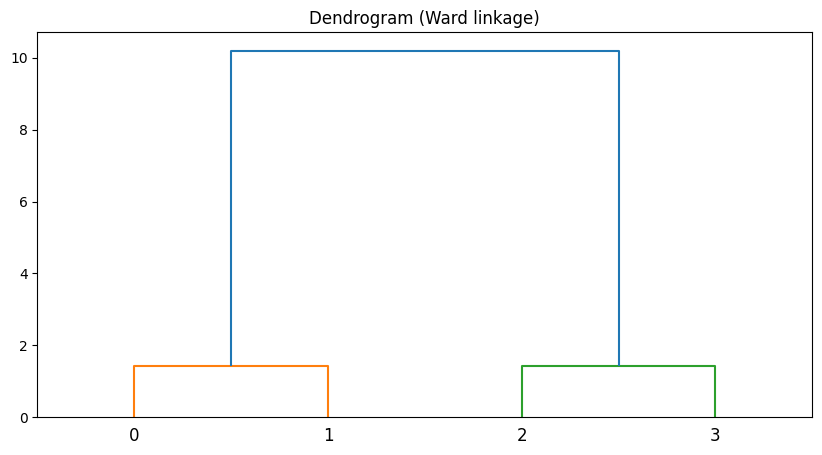

In [2]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import numpy as np

# Пример данных
X = np.array([[1, 2], [2, 3], [5, 8], [6, 9]])

# Применение разных методов связывания
Z_single = linkage(X, method='single')    # минимальное расстояние
Z_complete = linkage(X, method='complete')  # максимальное расстояние
Z_average = linkage(X, method='average')    # среднее расстояние
Z_ward = linkage(X, method='ward')          # дисперсионный метод (только для евклидовых расстояний)

# Визуализация дендрограммы
plt.figure(figsize=(10, 5))
dendrogram(Z_ward)  # можно подставить любой Z_* метод
plt.title("Dendrogram (Ward linkage)")
plt.show()

# Примеры использования метрик измерения расстояния между точками:

### Манхэттенское расстояние

In [3]:
from sklearn.metrics import pairwise_distances  # Импорт функции для вычисления попарных расстояний
import numpy as np

# Определяем первую точку (вектор признаков) — одномерный массив с 4 признаками
X = np.array([[3, 6, 11, 8]])

# Определяем вторую точку для сравнения
Y = np.array([[0, 9, 5, 3]])

# Вычисляем манхэттенское расстояние между X и Y
# Манхэттенское расстояние = сумма модулей разностей по каждой координате:
# |3-0| + |6-9| + |11-5| + |8-3| = 3 + 3 + 6 + 5 = 17
distances = pairwise_distances(X, Y, metric='manhattan')

# Выводим результат: матрица расстояний (в данном случае 1x1)
print(distances)

[[17.]]


### Евклидово расстояние

In [4]:
# Первая точка (вектор признаков)
X = np.array([[3, 6, 11, 8]])

# Вторая точка для сравнения
Y = np.array([[0, 9, 5, 3]])

# Вычисляем евклидово расстояние между X и Y
# Евклидово расстояние = корень из суммы квадратов разностей:
# sqrt((3-0)² + (6-9)² + (11-5)² + (8-3)²)
# sqrt(9 + 9 + 36 + 25) = sqrt(79) ≈ 8.888
distances = pairwise_distances(X, Y, metric='euclidean')

# Выводим матрицу расстояний (в данном случае 1x1)
print(distances)

[[8.88819442]]


Примечание: Стоит помнить, что использование методов средней и полной связи приносит хорошие результаты, только если данные имеют высокую плотность и не пересекаются или однородно распределены. В остальных случаях данные методы отрабатывают плохо и стоит использовать метод одиночной связи.

Для реализации алгоритма в sklearn вам понадобится __AgglomerativeClustering__. Обычно ему передают следующие параметры:

- n_clusters — количество кластеров; по умолчанию — 2.
- linkage — метод определения расстояния между кластерами, которое мы рассматривали выше.
- affinity — метод определения расстояний между точками (например, евклидово или манхэттенское).

### Плюсы:
- можно построить дендрограмму и понять, как устроены данные;
- работает даже на небольшом датасете.

### Минусы:
- необходимо выбирать оптимальное количество кластеров либо оптимальное расстояние в момент инициализации алгоритма;
- если данных много, дендрограмма становится большой и сложной для понимания;
- может неравномерно разделять данные на кластеры.